Use random forest regression to predict the amount of building
materials released from a demolition site.

## Imports

In [176]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

## Data

In [177]:
real_data = pd.read_csv("./data/vattuniemi.csv")
generated_data = pd.read_csv("./data/generated_data.csv")
# Switch to select either real or generated data
data = real_data

X = data[["Area", "Storeys"]].values
concrete = data[["Concrete"]].values
mineral_wool = data[["Mineral_wool"]].values
metal = data[["Metal"]].values
glass = data[["Glass"]].values


# Fit & test

0.2810025006910938


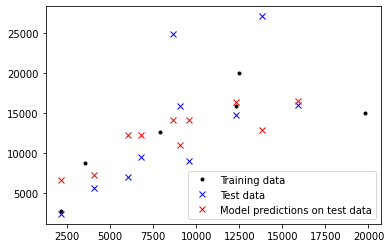

In [191]:
regr = RandomForestRegressor(max_depth=2, min_samples_split=3, min_samples_leaf=1)

# Replace the argument with {concrete, mineral_wool, glass, metal}
# to select material to predict.
y = np.ravel(concrete)
X_tr, X_tst, y_tr, y_tst = train_test_split(
   X, y, test_size=0.6, random_state=42)

# X_tr = real_data[["Area", "Storeys", "Concrete"]].iloc[:, :-1].values
# y_tr = real_data[["Area", "Storeys", "Concrete"]].iloc[:, -1].values
# X_tst = generated_data[["Area", "Storeys", "Concrete"]].iloc[:, :-1].values
# y_tst = generated_data[["Area", "Storeys", "Concrete"]].iloc[:, -1].values

regr.fit(X_tr, y_tr)
y_pred = regr.predict(X_tst)
print(regr.score(X_tst, y_tst))

fig = plt.figure()
plt.plot(X_tr[:, 0], y_tr, '.k', label='Training data')
plt.plot(X_tst[:, 0], y_tst, 'bx', label='Test data')
plt.plot(X_tst[:, 0], y_pred, 'rx', label='Model predictions on test data')
plt.legend()
plt.show()
